# Notebook 23 - TimTrack sequence with MATLAB-style `dohough` alpha

This is notebook 12 plus the new angle estimator.

What changes:

- The fascicle mask still comes from the current Python Frangi path.
- The selected line is still kept for visualization and old-style length diagnostics.
- The main `fascicle_angle_deg` now comes from MATLAB-style `dohough + weighted_median`.
- `pennation_angle_deg` is now computed as `alpha - superficial_aponeurosis_angle`, matching MATLAB `geofeatures.phi`.

This notebook writes separate outputs so notebook 12's original results stay untouched.

In [1]:
import os
import sys
from pathlib import Path
import importlib

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")

%load_ext autoreload
%autoreload 2

current = Path.cwd()

if (current / "ultrasound_tracker").exists():
    PROJECT_ROOT = current
elif (current.parent / "ultrasound_tracker").exists():
    PROJECT_ROOT = current.parent
else:
    raise FileNotFoundError("Could not find ultrasound_tracker folder")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = /Users/grosbedou/PycharmProjects/NDORMS


In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import ultrasound_tracker.roi as roi
import ultrasound_tracker.geometry as geom
import ultrasound_tracker.utils as ut

from ultrasound_tracker.aponeurosis_detector import AponeurosisDetector
from ultrasound_tracker.frangi_detector import FrangiDetector
from ultrasound_tracker.hough_detector import HoughDetector
from ultrasound_tracker.matlab_compat import (
    compute_metrics,
    extract_geofeature_arrays,
    load_matlab_result,
)
from ultrasound_tracker.timtrack_hough import DoHoughParams, dohough

roi = importlib.reload(roi)
geom = importlib.reload(geom)
ut = importlib.reload(ut)

print("ROI file:", roi.__file__)
print("Geometry file:", geom.__file__)
print("Utils file:", ut.__file__)

ROI file: /Users/grosbedou/PycharmProjects/NDORMS/ultrasound_tracker/roi.py
Geometry file: /Users/grosbedou/PycharmProjects/NDORMS/ultrasound_tracker/geometry.py
Utils file: /Users/grosbedou/PycharmProjects/NDORMS/ultrasound_tracker/utils.py


In [3]:
VIDEO_PATH = PROJECT_ROOT / "data" / "raw" / "UltraTimTrack_test.mp4"
ROI_PATH = PROJECT_ROOT / "data" / "rois" / "UltraTimTrack_test_rois.json"
MATLAB_RESULT = PROJECT_ROOT / "data" / "matlab" / "slow_low_01_DOWN_tracked_Q=001.mat"

RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

OUT_CSV = RESULTS_DIR / "timtrack_sequence_dohough_alpha_features.csv"
OUT_NPZ = RESULTS_DIR / "timtrack_sequence_dohough_alpha_features_arrays.npz"

FRAME_START = 0
FRAME_END = None
FRAME_STEP = 1

FASCICLE_METHOD = "frangi"

print("VIDEO_PATH:", VIDEO_PATH)
print("ROI_PATH:", ROI_PATH)
print("OUT_CSV:", OUT_CSV)
print("OUT_NPZ:", OUT_NPZ)

VIDEO_PATH: /Users/grosbedou/PycharmProjects/NDORMS/data/raw/UltraTimTrack_test.mp4
ROI_PATH: /Users/grosbedou/PycharmProjects/NDORMS/data/rois/UltraTimTrack_test_rois.json
OUT_CSV: /Users/grosbedou/PycharmProjects/NDORMS/results/timtrack_sequence_dohough_alpha_features.csv
OUT_NPZ: /Users/grosbedou/PycharmProjects/NDORMS/results/timtrack_sequence_dohough_alpha_features_arrays.npz


FPS: 33.341
Number of frames: 2667
Frame shape: (562, 706)
ROIs: {'superficial': (15, 21, 690, 42), 'deep': (16, 298, 689, 76), 'fascicle': (17, 65, 686, 226)}


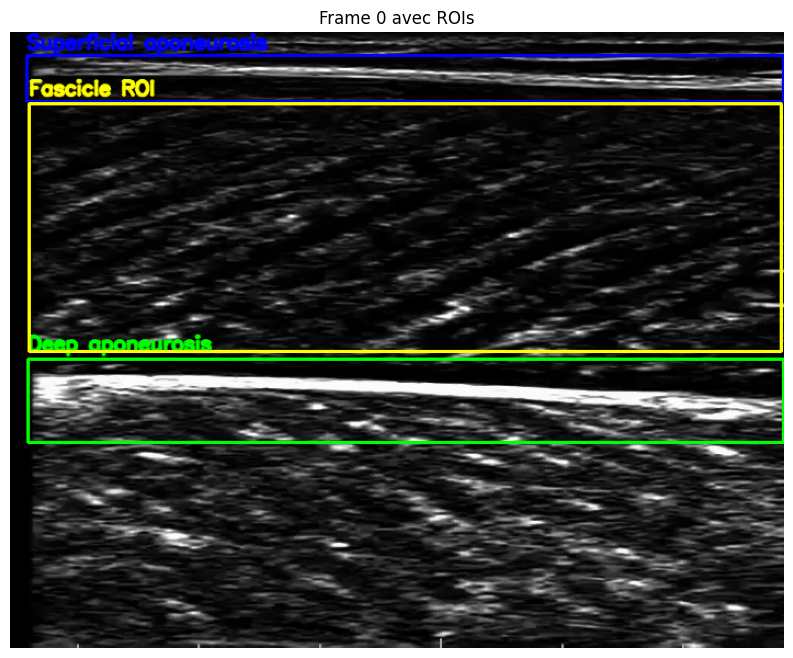

In [4]:
rois = roi.load_rois(ROI_PATH)

cap = cv2.VideoCapture(str(VIDEO_PATH))
fps = cap.get(cv2.CAP_PROP_FPS)
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

ret, frame0 = cap.read()
cap.release()

if not ret:
    raise RuntimeError(f"Could not read video: {VIDEO_PATH}")

if frame0.ndim == 3:
    frame0_gray = cv2.cvtColor(frame0, cv2.COLOR_BGR2GRAY)
else:
    frame0_gray = frame0.copy()

print("FPS:", fps)
print("Number of frames:", n_frames)
print("Frame shape:", frame0_gray.shape)
print("ROIs:", rois)

vis_rois = roi.draw_rois(frame0_gray, rois)

plt.figure(figsize=(14, 8))
plt.imshow(vis_rois[..., ::-1])
plt.title("Frame 0 avec ROIs")
plt.axis("off")
plt.show()

In [5]:
apo_detector = AponeurosisDetector(
    method="frangi",
    sigma=10.0,
    th=0.5,
    filtfac=1.0,
    maxlengthratio=0.9,
    frangi_scale_range=(18, 20),
    frangi_scale_ratio=1,
    frangi_black_ridges=False,
    apomargin=20,
    napo=10,
    fillgap=50,
    fit_method="enforce_maxangle",
    maxangle=0.5,
    adaptive_block_size=51,
)

fas_frangi_detector = FrangiDetector(
    sigmas=(1, 2, 4),
    alpha=0.5,
    beta=15.0,
    black_ridges=False,
    threshold=0.08,
    angle_min=10,
    angle_max=70,
    hough_threshold=15,
    min_line_length=25,
    max_line_gap=15,
)

fas_hough_detector = HoughDetector(
    angle_min=10,
    angle_max=70,
    canny_low=30,
    canny_high=90,
    hough_threshold=50,
    min_line_length=30,
    max_line_gap=10,
)

dohough_params = DoHoughParams(
    angle_range=(8.0, 80.0),
    thetares=1.0,
    rhores=1.0,
    emask_radius=(rois["fascicle"][3] / 2.0, rois["fascicle"][2] / 2.0),
    npeaks=10,
    replace_diagonal_bias=True,
)

print("Aponeurosis detector: Frangi")
print("Fascicle detector:", FASCICLE_METHOD)
print("Alpha estimator: MATLAB-style dohough + weighted median")
print("DoHough params:", dohough_params)

Aponeurosis detector: Frangi
Fascicle detector: frangi
Alpha estimator: MATLAB-style dohough + weighted median
DoHough params: DoHoughParams(houghangles='specified', angle_range=(8.0, 80.0), thetares=1.0, rhores=1.0, emask_radius=(113.0, 343.0), npeaks=10, show=False, replace_diagonal_bias=True)


In [6]:
def line_angle_deg(line):
    return geom.normalize_angle(geom.line_angle_from_array(line), degrees=True)

def y_at_x(line, x):
    x1, y1, x2, y2 = np.asarray(line, dtype=float)
    if abs(x2 - x1) < 1e-12:
        return np.nan
    slope = (y2 - y1) / (x2 - x1)
    return y1 + slope * (x - x1)

def matlab_style_length_from_apos(super_line, deep_line, alpha_deg, x_eval=20.0):
    super_angle = line_angle_deg(super_line)
    phi = alpha_deg - super_angle
    super_y = y_at_x(super_line, x_eval)
    deep_y = y_at_x(deep_line, x_eval)
    thickness = (deep_y - super_y) * np.cos(np.deg2rad(super_angle))
    denom = np.sin(np.deg2rad(phi))
    if not np.isfinite(denom) or abs(denom) < 1e-12:
        return np.nan, thickness, phi
    return thickness / denom, thickness, phi

def frangi_mask_and_lines(fas_img, detector):
    vesselness = detector.get_vesselness_map(fas_img)
    binary_bool = vesselness >= detector.threshold
    binary_u8 = binary_bool.astype(np.uint8) * 255

    raw_lines = cv2.HoughLinesP(
        binary_u8,
        rho=1,
        theta=np.pi / 180,
        threshold=detector.hough_threshold,
        minLineLength=detector.min_line_length,
        maxLineGap=detector.max_line_gap,
    )

    if raw_lines is None:
        return binary_bool, None, None, None

    lines = raw_lines[:, 0, :].astype(np.float32)
    signed_angles = geom.line_angles_batch(lines, degrees=True)
    abs_angles = np.abs(signed_angles)
    lengths = geom.line_lengths_batch(lines)
    keep = (abs_angles >= detector.angle_min) & (abs_angles <= detector.angle_max)

    filtered_lines = lines[keep]
    filtered_angles = abs_angles[keep]
    filtered_lengths = lengths[keep]

    if len(filtered_lines) == 0:
        return binary_bool, None, None, None

    return binary_bool, filtered_lines, filtered_angles, filtered_lengths

In [7]:
if FRAME_END is None:
    frame_end_effective = n_frames
else:
    frame_end_effective = min(FRAME_END, n_frames)

frame_indices = list(range(FRAME_START, frame_end_effective, FRAME_STEP))

print("Frames to process:", len(frame_indices))
print("First frame:", frame_indices[0])
print("Last frame:", frame_indices[-1])

Frames to process: 2667
First frame: 0
Last frame: 2666


In [8]:
results = {
    "frame": [],
    "time_s": [],
    "success": [],
    "fascicle_length_px": [],
    "fascicle_angle_deg": [],
    "pennation_angle_deg": [],
    "super_apo_angle_deg": [],
    "deep_apo_angle_deg": [],
    "selected_line_angle_deg": [],
    "selected_line_length_px": [],
    "matlab_formula_fascicle_length_px": [],
    "muscle_thickness_px": [],
    "dohough_mask_density": [],
    "dohough_n_peaks": [],
    "n_fascicle_candidates": [],
    "error": [],
}

sup_apo_lines = []
deep_apo_lines = []
fascicle_lines = []
fascicle_segments = []
sup_attachments = []
deep_attachments = []
dohough_peak_alphas = []
dohough_peak_weights = []

In [9]:
cap = cv2.VideoCapture(str(VIDEO_PATH))

target_frames = set(frame_indices)

for frame_idx in range(n_frames):
    ret, frame = cap.read()

    if not ret:
        break

    if frame_idx not in target_frames:
        continue

    if frame.ndim == 3:
        frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    else:
        frame_gray = frame.copy()

    time_s = frame_idx / fps if fps and fps > 0 else np.nan

    success = False
    error_msg = ""
    n_candidates = 0

    sup_line_global = np.full(4, np.nan, dtype=np.float32)
    deep_line_global = np.full(4, np.nan, dtype=np.float32)
    fas_best_line_global = np.full(4, np.nan, dtype=np.float32)
    fas_segment = np.full(4, np.nan, dtype=np.float32)
    sup_attachment = np.full(2, np.nan, dtype=np.float32)
    deep_attachment = np.full(2, np.nan, dtype=np.float32)
    peak_alphas = np.full(10, np.nan, dtype=np.float32)
    peak_weights = np.full(10, np.nan, dtype=np.float32)

    fascicle_length_px = np.nan
    fascicle_angle_deg = np.nan
    pennation_angle_deg = np.nan
    super_apo_angle_deg = np.nan
    deep_apo_angle_deg = np.nan
    selected_line_angle_deg = np.nan
    selected_line_length_px = np.nan
    matlab_formula_fascicle_length_px = np.nan
    muscle_thickness_px = np.nan
    dohough_mask_density = np.nan
    dohough_n_peaks = 0

    try:
        sup_img = roi.extract_roi(frame_gray, rois["superficial"])
        deep_img = roi.extract_roi(frame_gray, rois["deep"])
        fas_img = roi.extract_roi(frame_gray, rois["fascicle"])

        sup_result = apo_detector.detect(sup_img, kind="superficial")
        sup_line_local = sup_result["line_local"]
        sup_line_tmp = roi.line_local_to_global(sup_line_local, rois["superficial"])

        deep_result = apo_detector.detect(deep_img, kind="deep")
        deep_line_local = deep_result["line_local"]
        deep_line_tmp = roi.line_local_to_global(deep_line_local, rois["deep"])

        if sup_line_tmp is None:
            raise RuntimeError("No superficial aponeurosis detected.")

        if deep_line_tmp is None:
            raise RuntimeError("No deep aponeurosis detected.")

        if FASCICLE_METHOD.lower() == "frangi":
            fas_binary, fas_lines_local, fas_angles, fas_lengths = frangi_mask_and_lines(
                fas_img,
                fas_frangi_detector,
            )
        elif FASCICLE_METHOD.lower() == "hough":
            fas_lines_local, fas_angles, fas_lengths = fas_hough_detector.detect(fas_img)
            fas_binary = np.zeros(fas_img.shape, dtype=bool)
        else:
            raise ValueError("FASCICLE_METHOD must be 'frangi' or 'hough'.")

        hough_result = dohough(fas_binary, dohough_params)
        fascicle_angle_deg = float(hough_result["alpha"])
        dohough_mask_density = float(np.mean(fas_binary))
        dohough_n_peaks = int(len(hough_result["alphas"]))
        if dohough_n_peaks:
            n_fill = min(10, dohough_n_peaks)
            peak_alphas[:n_fill] = hough_result["alphas"][:n_fill]
            peak_weights[:n_fill] = hough_result["weights"][:n_fill]

        if not np.isfinite(fascicle_angle_deg):
            raise RuntimeError("No dohough fascicle alpha detected.")

        fas_lines_global = roi.lines_local_to_global(fas_lines_local, rois["fascicle"])
        n_candidates = 0 if fas_lines_global is None else len(fas_lines_global)

        fas_best_tmp = geom.pick_best_fascicle_line(
            fas_lines_global,
            lengths=fas_lengths,
            superficial_apo_line=sup_line_tmp,
            deep_apo_line=deep_line_tmp,
            frame_shape=frame_gray.shape,
            margin=50,
        )

        if fas_best_tmp is None:
            raise RuntimeError("No fascicle line selected for visualization/length.")

        geometry_features = geom.compute_fascicle_geometry(
            superficial_apo_line=sup_line_tmp,
            deep_apo_line=deep_line_tmp,
            fascicle_line=fas_best_tmp,
        )

        success = True

        sup_line_global = np.asarray(sup_line_tmp, dtype=np.float32)
        deep_line_global = np.asarray(deep_line_tmp, dtype=np.float32)
        fas_best_line_global = np.asarray(fas_best_tmp, dtype=np.float32)

        fas_segment = np.asarray(
            geometry_features["fascicle_segment_between_apos"],
            dtype=np.float32,
        )
        sup_attachment = np.asarray(geometry_features["sup_attachment"], dtype=np.float32)
        deep_attachment = np.asarray(geometry_features["deep_attachment"], dtype=np.float32)

        selected_line_angle_deg = geometry_features["fascicle_angle_deg"]
        selected_line_length_px = geometry_features["fascicle_length_px"]
        fascicle_length_px = selected_line_length_px

        super_apo_angle_deg = line_angle_deg(sup_line_global)
        deep_apo_angle_deg = line_angle_deg(deep_line_global)
        pennation_angle_deg = fascicle_angle_deg - super_apo_angle_deg

        (
            matlab_formula_fascicle_length_px,
            muscle_thickness_px,
            _,
        ) = matlab_style_length_from_apos(
            sup_line_global,
            deep_line_global,
            fascicle_angle_deg,
            x_eval=20.0,
        )

    except Exception as exc:
        error_msg = str(exc)

    results["frame"].append(frame_idx)
    results["time_s"].append(time_s)
    results["success"].append(success)
    results["fascicle_length_px"].append(fascicle_length_px)
    results["fascicle_angle_deg"].append(fascicle_angle_deg)
    results["pennation_angle_deg"].append(pennation_angle_deg)
    results["super_apo_angle_deg"].append(super_apo_angle_deg)
    results["deep_apo_angle_deg"].append(deep_apo_angle_deg)
    results["selected_line_angle_deg"].append(selected_line_angle_deg)
    results["selected_line_length_px"].append(selected_line_length_px)
    results["matlab_formula_fascicle_length_px"].append(matlab_formula_fascicle_length_px)
    results["muscle_thickness_px"].append(muscle_thickness_px)
    results["dohough_mask_density"].append(dohough_mask_density)
    results["dohough_n_peaks"].append(dohough_n_peaks)
    results["n_fascicle_candidates"].append(n_candidates)
    results["error"].append(error_msg)

    sup_apo_lines.append(sup_line_global)
    deep_apo_lines.append(deep_line_global)
    fascicle_lines.append(fas_best_line_global)
    fascicle_segments.append(fas_segment)
    sup_attachments.append(sup_attachment)
    deep_attachments.append(deep_attachment)
    dohough_peak_alphas.append(peak_alphas)
    dohough_peak_weights.append(peak_weights)

    if len(results["frame"]) % 100 == 0:
        n_done = len(results["frame"])
        n_success = int(np.sum(results["success"]))
        print(f"Processed {n_done}/{len(frame_indices)} frames — success {n_success}")

cap.release()

print("Done.")
print("Processed:", len(results["frame"]))
print("Successful:", int(np.sum(results["success"])))

/Users/grosbedou/PycharmProjects/NDORMS/ultrasound_tracker/aponeurosis_detector.py:109: FutureWarning: `RegionProperties.major_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_major_length` instead. 
  key=lambda p: p.major_axis_length,
/Users/grosbedou/PycharmProjects/NDORMS/ultrasound_tracker/aponeurosis_detector.py:120: FutureWarning: `RegionProperties.major_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_major_length` instead. 
  lengths = [p.major_axis_length for p in top2]
/Users/grosbedou/PycharmProjects/NDORMS/ultrasound_tracker/aponeurosis_detector.py:126: FutureWarning: `RegionProperties.major_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_major_length` instead. 
  best = max(top2, key=lambda p: p.major_axis_length)


Processed 100/2667 frames — success 100


Processed 200/2667 frames — success 200


Processed 300/2667 frames — success 300


Processed 400/2667 frames — success 400


...

Processed 2300/2667 frames — success 2300


Processed 2400/2667 frames — success 2400


Processed 2500/2667 frames — success 2500


Processed 2600/2667 frames — success 2600


Done.
Processed: 2667
Successful: 2667


In [10]:
sup_apo_lines_arr = np.vstack(sup_apo_lines).astype(np.float32)
deep_apo_lines_arr = np.vstack(deep_apo_lines).astype(np.float32)
fascicle_lines_arr = np.vstack(fascicle_lines).astype(np.float32)
fascicle_segments_arr = np.vstack(fascicle_segments).astype(np.float32)
sup_attachments_arr = np.vstack(sup_attachments).astype(np.float32)
deep_attachments_arr = np.vstack(deep_attachments).astype(np.float32)
dohough_peak_alphas_arr = np.vstack(dohough_peak_alphas).astype(np.float32)
dohough_peak_weights_arr = np.vstack(dohough_peak_weights).astype(np.float32)

ut.save_results(results, str(OUT_CSV))

np.savez(
    OUT_NPZ,
    frame=np.asarray(results["frame"], dtype=np.int32),
    time_s=np.asarray(results["time_s"], dtype=np.float32),
    success=np.asarray(results["success"], dtype=bool),
    sup_apo_lines=sup_apo_lines_arr,
    deep_apo_lines=deep_apo_lines_arr,
    fascicle_lines=fascicle_lines_arr,
    fascicle_segments=fascicle_segments_arr,
    sup_attachments=sup_attachments_arr,
    deep_attachments=deep_attachments_arr,
    fascicle_length_px=np.asarray(results["fascicle_length_px"], dtype=np.float32),
    fascicle_angle_deg=np.asarray(results["fascicle_angle_deg"], dtype=np.float32),
    pennation_angle_deg=np.asarray(results["pennation_angle_deg"], dtype=np.float32),
    super_apo_angle_deg=np.asarray(results["super_apo_angle_deg"], dtype=np.float32),
    deep_apo_angle_deg=np.asarray(results["deep_apo_angle_deg"], dtype=np.float32),
    selected_line_angle_deg=np.asarray(results["selected_line_angle_deg"], dtype=np.float32),
    selected_line_length_px=np.asarray(results["selected_line_length_px"], dtype=np.float32),
    matlab_formula_fascicle_length_px=np.asarray(results["matlab_formula_fascicle_length_px"], dtype=np.float32),
    muscle_thickness_px=np.asarray(results["muscle_thickness_px"], dtype=np.float32),
    dohough_mask_density=np.asarray(results["dohough_mask_density"], dtype=np.float32),
    dohough_n_peaks=np.asarray(results["dohough_n_peaks"], dtype=np.int32),
    dohough_peak_alphas=dohough_peak_alphas_arr,
    dohough_peak_weights=dohough_peak_weights_arr,
    n_fascicle_candidates=np.asarray(results["n_fascicle_candidates"], dtype=np.int32),
)

print("Saved CSV:", OUT_CSV)
print("Saved NPZ:", OUT_NPZ)

Résultats sauvegardés : /Users/grosbedou/PycharmProjects/NDORMS/results/timtrack_sequence_dohough_alpha_features.csv
Saved CSV: /Users/grosbedou/PycharmProjects/NDORMS/results/timtrack_sequence_dohough_alpha_features.csv
Saved NPZ: /Users/grosbedou/PycharmProjects/NDORMS/results/timtrack_sequence_dohough_alpha_features_arrays.npz


In [11]:
success_arr = np.asarray(results["success"], dtype=bool)
frames_arr = np.asarray(results["frame"])
time_arr = np.asarray(results["time_s"], dtype=np.float32)

length_arr = np.asarray(results["fascicle_length_px"], dtype=np.float32)
formula_length_arr = np.asarray(results["matlab_formula_fascicle_length_px"], dtype=np.float32)
pennation_arr = np.asarray(results["pennation_angle_deg"], dtype=np.float32)
fascicle_angle_arr = np.asarray(results["fascicle_angle_deg"], dtype=np.float32)
selected_angle_arr = np.asarray(results["selected_line_angle_deg"], dtype=np.float32)

print("Total processed:", len(success_arr))
print("Successful:", np.sum(success_arr))
print("Failed:", np.sum(~success_arr))
print("Success rate:", 100 * np.mean(success_arr), "%")

if np.any(success_arr):
    print("\nDohough alpha deg:")
    print("  mean:", np.nanmean(fascicle_angle_arr))
    print("  std :", np.nanstd(fascicle_angle_arr))
    print("  min :", np.nanmin(fascicle_angle_arr))
    print("  max :", np.nanmax(fascicle_angle_arr))

    print("\nSelected-line alpha deg:")
    print("  mean:", np.nanmean(selected_angle_arr))
    print("  std :", np.nanstd(selected_angle_arr))

    print("\nPennation deg:")
    print("  mean:", np.nanmean(pennation_arr))
    print("  std :", np.nanstd(pennation_arr))

    print("\nSelected segment length px:")
    print("  mean:", np.nanmean(length_arr))
    print("  std :", np.nanstd(length_arr))

    print("\nMATLAB formula length px:")
    print("  mean:", np.nanmean(formula_length_arr))
    print("  std :", np.nanstd(formula_length_arr))

Total processed: 2667
Successful: 2667
Failed: 0
Success rate: 100.0 %

Dohough alpha deg:
  mean: 27.87589
  std : 4.535074
  min : 19.0
  max : 38.0

Selected-line alpha deg:
  mean: 14.1685
  std : 13.689

Pennation deg:
  mean: 28.600443
  std : 4.26419

Selected segment length px:
  mean: 762.6471
  std : 59.98428

MATLAB formula length px:
  mean: 556.7251
  std : 95.93254


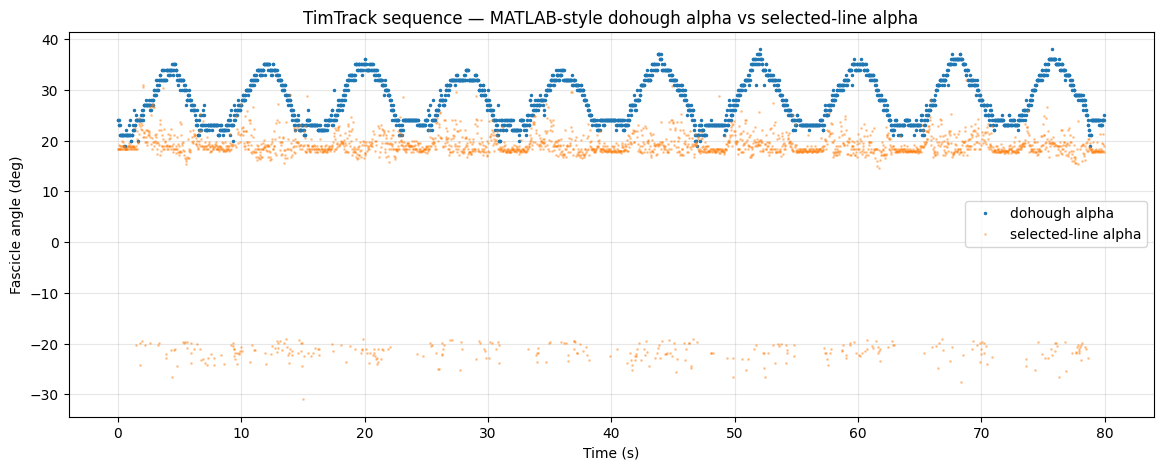

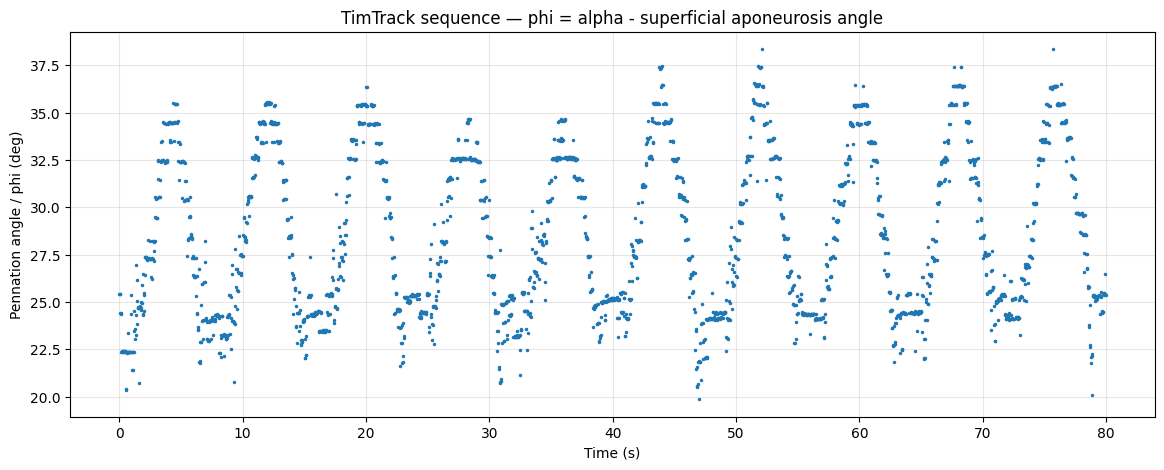

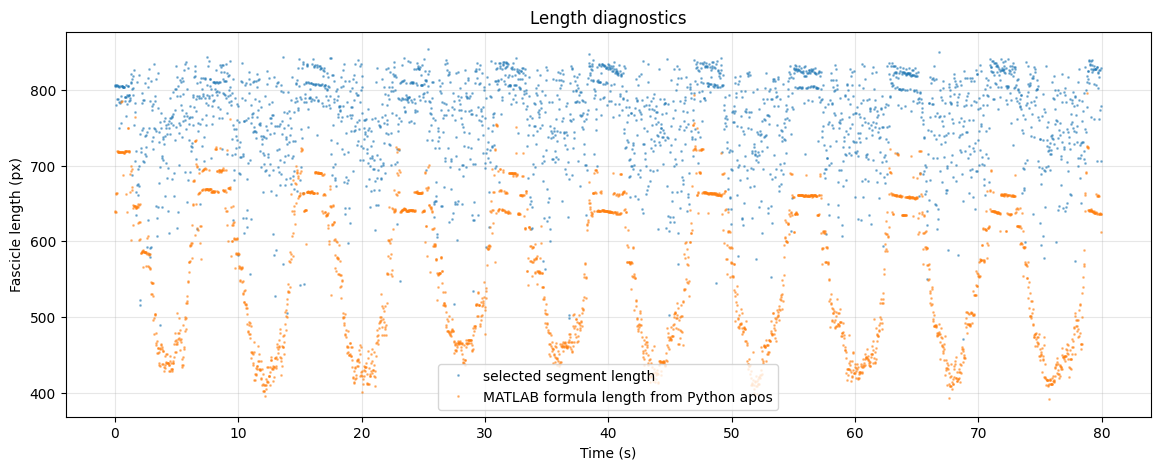

In [12]:
plt.figure(figsize=(14, 5))
plt.plot(time_arr, fascicle_angle_arr, ".", markersize=3, label="dohough alpha")
plt.plot(time_arr, selected_angle_arr, ".", markersize=2, alpha=0.35, label="selected-line alpha")
plt.xlabel("Time (s)")
plt.ylabel("Fascicle angle (deg)")
plt.title("TimTrack sequence — MATLAB-style dohough alpha vs selected-line alpha")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(time_arr, pennation_arr, ".", markersize=3)
plt.xlabel("Time (s)")
plt.ylabel("Pennation angle / phi (deg)")
plt.title("TimTrack sequence — phi = alpha - superficial aponeurosis angle")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(time_arr, length_arr, ".", markersize=2, alpha=0.45, label="selected segment length")
plt.plot(time_arr, formula_length_arr, ".", markersize=2, alpha=0.45, label="MATLAB formula length from Python apos")
plt.xlabel("Time (s)")
plt.ylabel("Fascicle length (px)")
plt.title("Length diagnostics")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

,comparison,n,bias,mae,rmse,corr
0,alpha: current selected-line,2666,-11.390793,11.659603,18.967960,-0.096262
1,alpha: notebook23 dohough,2666,2.319392,2.526819,3.537244,0.866061
2,phi: notebook23 alpha-super,2666,1.907597,2.344573,3.339665,0.846340
3,faslen: selected segment,2666,146.038386,155.143503,183.660677,0.373588
4,faslen: MATLAB formula with Python apos,2666,-59.888178,62.439799,87.690616,0.843224


Saved metrics: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_comparison/notebook23_dohough_alpha_metrics.csv


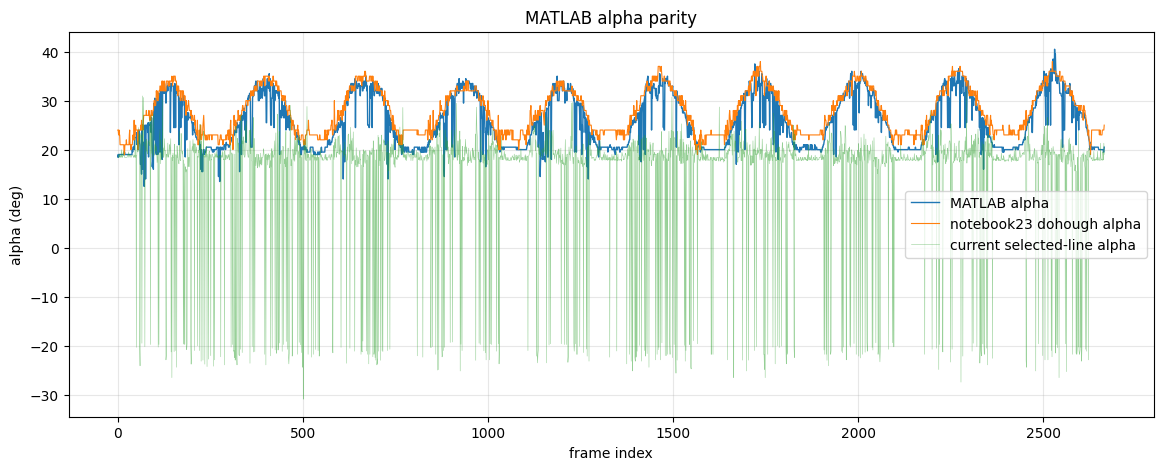

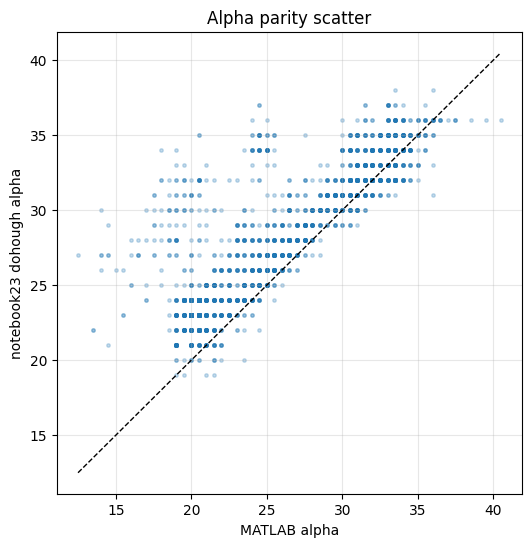

In [13]:
mat = load_matlab_result(MATLAB_RESULT)
matlab_geo = extract_geofeature_arrays(mat)

n_compare = min(len(matlab_geo["alpha_deg"]), len(fascicle_angle_arr))

def row(name, reference, estimate):
    out = {"comparison": name}
    out.update(compute_metrics(reference[:n_compare], estimate[:n_compare]))
    return out

metrics = pd.DataFrame([
    row("alpha: current selected-line", matlab_geo["alpha_deg"], selected_angle_arr),
    row("alpha: notebook23 dohough", matlab_geo["alpha_deg"], fascicle_angle_arr),
    row("phi: notebook23 alpha-super", matlab_geo["phi_deg"], pennation_arr),
    row("faslen: selected segment", matlab_geo["faslen_px"], length_arr),
    row("faslen: MATLAB formula with Python apos", matlab_geo["faslen_px"], formula_length_arr),
])

display(metrics)

metrics_path = PROJECT_ROOT / "results" / "matlab_comparison" / "notebook23_dohough_alpha_metrics.csv"
metrics_path.parent.mkdir(parents=True, exist_ok=True)
metrics.to_csv(metrics_path, index=False)
print("Saved metrics:", metrics_path)

plt.figure(figsize=(14, 5))
plt.plot(matlab_geo["alpha_deg"][:n_compare], label="MATLAB alpha", linewidth=1)
plt.plot(fascicle_angle_arr[:n_compare], label="notebook23 dohough alpha", linewidth=0.8)
plt.plot(selected_angle_arr[:n_compare], label="current selected-line alpha", linewidth=0.4, alpha=0.5)
plt.ylabel("alpha (deg)")
plt.xlabel("frame index")
plt.title("MATLAB alpha parity")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(matlab_geo["alpha_deg"][:n_compare], fascicle_angle_arr[:n_compare], s=6, alpha=0.25)
lo = np.nanmin(matlab_geo["alpha_deg"][:n_compare])
hi = np.nanmax(matlab_geo["alpha_deg"][:n_compare])
plt.plot([lo, hi], [lo, hi], "k--", linewidth=1)
plt.xlabel("MATLAB alpha")
plt.ylabel("notebook23 dohough alpha")
plt.title("Alpha parity scatter")
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
valid_indices = np.where(success_arr)[0]

if len(valid_indices) == 0:
    raise RuntimeError("No successful frames to visualize.")

selected_result_indices = [
    valid_indices[0],
    valid_indices[len(valid_indices) // 2],
    valid_indices[-1],
]

print("Selected result indices:", selected_result_indices)
print("Selected frame numbers:", [results["frame"][i] for i in selected_result_indices])

Selected result indices: [np.int64(0), np.int64(1333), np.int64(2666)]
Selected frame numbers: [0, 1333, 2666]


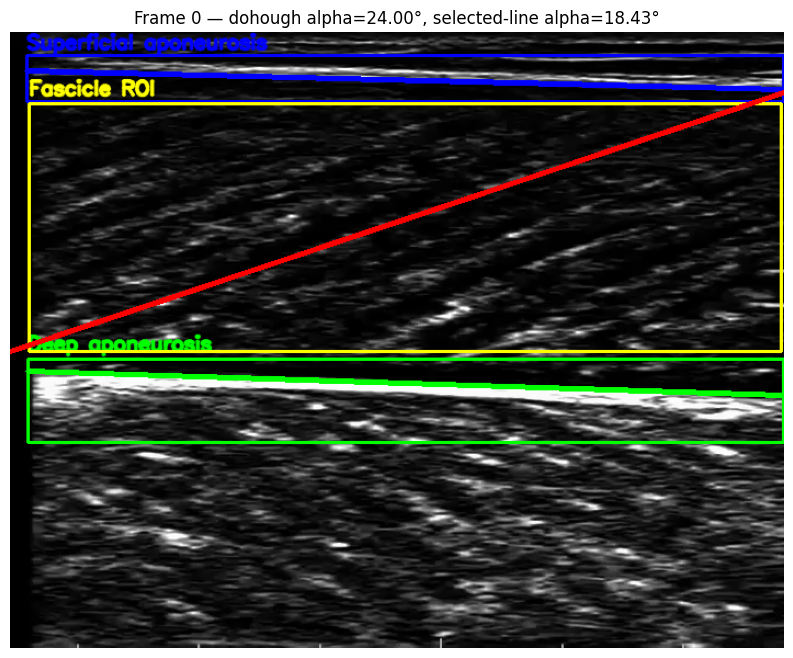

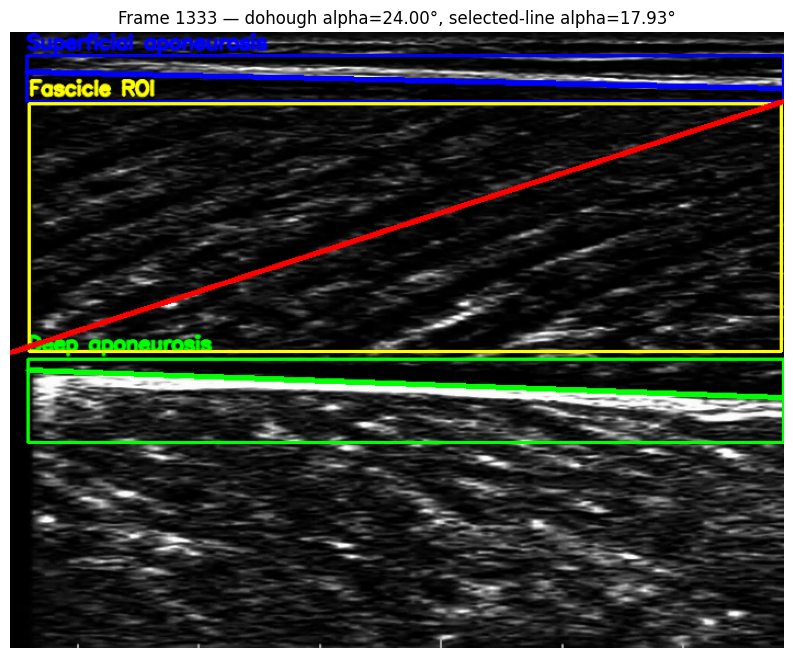

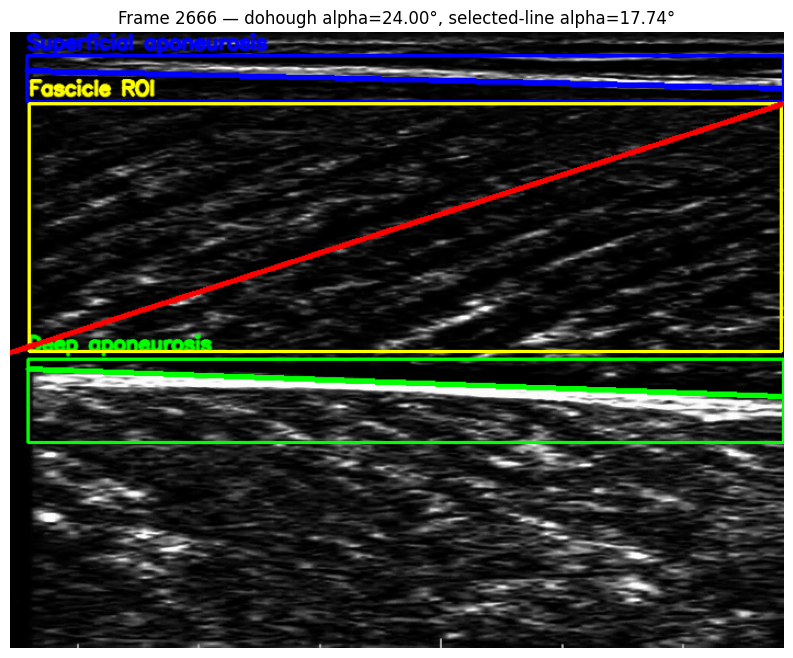

In [15]:
for result_idx in selected_result_indices:
    frame_idx = int(results["frame"][result_idx])

    cap = cv2.VideoCapture(str(VIDEO_PATH))
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    cap.release()

    if not ret:
        print("Could not read frame", frame_idx)
        continue

    if frame.ndim == 3:
        frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    else:
        frame_gray = frame.copy()

    vis = roi.draw_rois(frame_gray, rois)

    ut.draw_line_on_image(vis, sup_apo_lines_arr[result_idx], color=(255, 0, 0), thickness=3)
    ut.draw_line_on_image(vis, deep_apo_lines_arr[result_idx], color=(0, 255, 0), thickness=3)
    ut.draw_line_on_image(vis, fascicle_lines_arr[result_idx], color=(0, 255, 255), thickness=2)
    ut.draw_line_on_image(vis, fascicle_segments_arr[result_idx], color=(0, 0, 255), thickness=3)

    plt.figure(figsize=(14, 8))
    plt.imshow(vis[..., ::-1])
    plt.title(
        f"Frame {frame_idx} — dohough alpha={fascicle_angle_arr[result_idx]:.2f}°, "
        f"selected-line alpha={selected_angle_arr[result_idx]:.2f}°"
    )
    plt.axis("off")
    plt.show()